# Generación de series de 5 minutos — perturbación F3+nexp fixed-TPK

Notebook mínimo para generar tres series temporales a resolución de **5 minutos** entre **18:00 y 22:00 UTC**:

1. seed inicial común fixed-TPK;
2. best old ASLS fixed-TPK;
3. best Whittaker fixed-TPK.

La ejecución se distribuye en **3 workers**, con **1 worker por curva** y **1 hilo por worker**. No se usan los archivos old ASLS con `t_pk_s` libre.

Nota técnica: la seed inicial común se evalúa por defecto usando el background old ASLS. Si quieres evaluarla usando el background Whittaker, cambia `SEED_EVAL_BACKGROUND = :oldASLS` por `:whittaker` en la celda de configuración.

In [1]:

using Distributed
using LinearAlgebra
using HDF5
using Dates
using TimeZones
using DataFrames
import CSV

# Limitar paralelismo interno antes de crear workers.
ENV["JULIA_NUM_THREADS"] = "1"
ENV["OPENBLAS_NUM_THREADS"] = "1"
ENV["OMP_NUM_THREADS"] = "1"
ENV["MKL_NUM_THREADS"] = "1"
ENV["VECLIB_MAXIMUM_THREADS"] = "1"
ENV["NUMEXPR_NUM_THREADS"] = "1"
ENV["BLIS_NUM_THREADS"] = "1"
BLAS.set_num_threads(1)

OUTDIR = joinpath(pwd(), "series_5min_FIXED_TPK")
mkpath(OUTDIR)

println("OUTDIR = ", OUTDIR)
println("Main Threads.nthreads() = ", Threads.nthreads())
println("Main BLAS.get_num_threads() = ", BLAS.get_num_threads())

OUTDIR = /home/jp/basefolder_JP/series_5min_FIXED_TPK
Main Threads.nthreads() = 8
Main BLAS.get_num_threads() = 1


## 1. Rutas

Ejecuta el notebook desde tu carpeta de trabajo, por ejemplo `/home/jp/basefolder_JP`. Las rutas también pueden sobrescribirse con variables de entorno.

In [2]:

# ------------------------------------------------------------
# Archivos fixed-TPK de perturbación
# ------------------------------------------------------------
WHIT_FIRST_H5_NAME  = "new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_rel10_results_15517278.h5"
WHIT_SECOND_H5_NAME = "new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_restart_from15517278_rel10_z0wide20_results_15572093.h5"

OLD_FIRST_H5_NAME   = "new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_FIXED_TPK_rel10_results_15341092.h5"
OLD_SECOND_H5_NAME  = "new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_FIXED_TPK_rel10_seed_from_15341092_results_15373069.h5"

# ------------------------------------------------------------
# Backgrounds físicos/modelados usados por cada inversión
# ------------------------------------------------------------
WHIT_BG_H5_NAME = "new-real-background-inversion_from_sep_16_22_restart15_results_12976567.h5"
OLD_BG_H5_NAME  = "new-real-background-inversion-bbo_from_old_asls_restart_results_13341497.h5"

# Script fixed-TPK que lee BACKGROUND_H5 desde ENV.
SOURCE_SCRIPT_FIXED_TPK_NAME = "new-perturbation-data-inversion-bbo_F3_nexp_fixed_CLEAN_v3_oldASLS_BG_from_H5.jl"

# Seed común: elegir background para producir una serie.
SEED_EVAL_BACKGROUND = :oldASLS
@assert SEED_EVAL_BACKGROUND in (:oldASLS, :whittaker)

function find_existing_file(name_or_path::AbstractString; required::Bool = true)
    candidates = String[
        name_or_path,
        joinpath(pwd(), name_or_path),
        joinpath("/mnt/data", basename(name_or_path)),
    ]

    for p in unique(candidates)
        if isfile(p)
            return abspath(p)
        end
    end

    if required
        error("No encontré el archivo: $(name_or_path)")
    else
        return ""
    end
end

WHIT_FIRST_H5  = find_existing_file(get(ENV, "WHIT_FIRST_H5", WHIT_FIRST_H5_NAME))
WHIT_SECOND_H5 = find_existing_file(get(ENV, "WHIT_SECOND_H5", WHIT_SECOND_H5_NAME))
OLD_FIRST_H5   = find_existing_file(get(ENV, "OLD_FIRST_H5", OLD_FIRST_H5_NAME))
OLD_SECOND_H5  = find_existing_file(get(ENV, "OLD_SECOND_H5", OLD_SECOND_H5_NAME))
WHIT_BG_H5     = find_existing_file(get(ENV, "WHIT_BG_H5", WHIT_BG_H5_NAME))
OLD_BG_H5      = find_existing_file(get(ENV, "OLD_BG_H5", OLD_BG_H5_NAME))
SOURCE_SCRIPT_FIXED_TPK = find_existing_file(get(ENV, "SOURCE_SCRIPT_FIXED_TPK", SOURCE_SCRIPT_FIXED_TPK_NAME))

println("WHIT_FIRST_H5  = ", WHIT_FIRST_H5)
println("WHIT_SECOND_H5 = ", WHIT_SECOND_H5)
println("OLD_FIRST_H5   = ", OLD_FIRST_H5)
println("OLD_SECOND_H5  = ", OLD_SECOND_H5)
println("WHIT_BG_H5     = ", WHIT_BG_H5)
println("OLD_BG_H5      = ", OLD_BG_H5)
println("SOURCE_SCRIPT  = ", SOURCE_SCRIPT_FIXED_TPK)

WHIT_FIRST_H5  = /home/jp/basefolder_JP/new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_rel10_results_15517278.h5
WHIT_SECOND_H5 = /home/jp/basefolder_JP/new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_restart_from15517278_rel10_z0wide20_results_15572093.h5
OLD_FIRST_H5   = /home/jp/basefolder_JP/new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_FIXED_TPK_rel10_results_15341092.h5
OLD_SECOND_H5  = /home/jp/basefolder_JP/new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_FIXED_TPK_rel10_seed_from_15341092_results_15373069.h5
WHIT_BG_H5     = /home/jp/basefolder_JP/new-real-background-inversion_from_sep_16_22_restart15_results_12976567.h5
OLD_BG_H5      = /home/jp/basefolder_JP/new-real-background-inversion-bbo_from_old_asls_restart_results_13341497.h5
SOURCE_SCRIPT  = /home/jp/basefolder_JP/new-perturbation-data-inversion-bbo_F3_nexp_fixed_CLEAN_v3_oldASLS_BG_from_H5.jl


## 2. Cargar parámetros fixed-TPK

Se usa siempre `full_params`, porque la función F3+nexp espera 7 parámetros:

```text
[amp, t_pk_s_fixed, tau_u_s, tau_d_s, eps_s, z0_km, hz_km]
```

En estos archivos `t_pk_s_fixed = 1800 s` y no se optimiza.

In [3]:

function h5vec(path::AbstractString, key::AbstractString)
    h5open(path, "r") do f
        return Float64.(vec(read(f[key])))
    end
end

function clean_h5_string(x)
    if x isa AbstractString
        return replace(String(x), "\0" => "")
    elseif x isa Vector{UInt8}
        return replace(String(x), "\0" => "")
    elseif x isa Array{UInt8}
        return replace(String(vec(x)), "\0" => "")
    else
        return replace(string(x), "\0" => "")
    end
end

function h5attr(path::AbstractString, key::AbstractString; default = "")
    h5open(path, "r") do f
        attrs = HDF5.attributes(f)
        return haskey(attrs, key) ? clean_h5_string(read(attrs[key])) : default
    end
end

function h5attr_float(path::AbstractString, key::AbstractString; default = NaN)
    h5open(path, "r") do f
        attrs = HDF5.attributes(f)
        return haskey(attrs, key) ? Float64(read(attrs[key])) : default
    end
end

seed_full      = h5vec(WHIT_FIRST_H5,  "initial/full_params")
old_best_full  = h5vec(OLD_SECOND_H5,  "reconstruction/full_params")
whit_best_full = h5vec(WHIT_SECOND_H5, "reconstruction/full_params")

for p in (seed_full, old_best_full, whit_best_full)
    @assert length(p) == 7
    @assert isapprox(p[2], 1800.0; atol = 1e-8)
end

metadata_df = DataFrame(
    case = ["seed inicial común", "old ASLS best2", "Whittaker best2"],
    source_h5 = [basename(WHIT_FIRST_H5), basename(OLD_SECOND_H5), basename(WHIT_SECOND_H5)],
    background_h5 = [
        SEED_EVAL_BACKGROUND == :oldASLS ? basename(OLD_BG_H5) : basename(WHIT_BG_H5),
        basename(OLD_BG_H5),
        basename(WHIT_BG_H5),
    ],
    t_pk_s = [seed_full[2], old_best_full[2], whit_best_full[2]],
    params = [string(seed_full), string(old_best_full), string(whit_best_full)],
)

display(metadata_df)
CSV.write(joinpath(OUTDIR, "metadata_series_5min_FIXED_TPK.csv"), metadata_df)

Row,case,source_h5,background_h5,t_pk_s,params
,String,String,String,Float64,String
1,seed inicial común,new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_rel10_results_15517278.h5,new-real-background-inversion-bbo_from_old_asls_restart_results_13341497.h5,1800.0,"[20.0, 1800.0, 190.5781464, 1248.558552, 789.685128, 85.0, 10.0]"
2,old ASLS best2,new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_FIXED_TPK_rel10_seed_from_15341092_results_15373069.h5,new-real-background-inversion-bbo_from_old_asls_restart_results_13341497.h5,1800.0,"[20.51589272494843, 1800.0, 194.41667913701474, 1293.8621458306043, 761.7859323666472, 76.11048983660899, 10.779863522419255]"
3,Whittaker best2,new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_restart_from15517278_rel10_z0wide20_results_15572093.h5,new-real-background-inversion_from_sep_16_22_restart15_results_12976567.h5,1800.0,"[20.55366026497965, 1800.0, 192.4346486500968, 1322.1608277859061, 818.4896451572062, 74.24768709007736, 9.959799237547852]"


"/home/jp/basefolder_JP/series_5min_FIXED_TPK/metadata_series_5min_FIXED_TPK.csv"

## 3. Grilla temporal de 5 minutos

In [5]:
#=
UTC_TZ = TimeZone("UTC")

zdt0_5min = ZonedDateTime(2008, 3, 25, 18, 0, 0, UTC_TZ)
zdt_5min = [zdt0_5min + Minute(5 * (i - 1)) for i in 1:49]

t_hours_5min = [
    Dates.hour(DateTime(astimezone(t, UTC_TZ))) +
    Dates.minute(DateTime(astimezone(t, UTC_TZ))) / 60.0 +
    Dates.second(DateTime(astimezone(t, UTC_TZ))) / 3600.0
    for t in zdt_5min
]

timestamps_5min = Dates.datetime2unix.(
    DateTime.(astimezone.(zdt_5min, Ref(UTC_TZ)))
)

println("N puntos = ", length(zdt_5min))
println("inicio   = ", first(zdt_5min))
println("fin      = ", last(zdt_5min))

=#
UTC_TZ = TimeZone("UTC")

zdt0_5min = ZonedDateTime(2008, 3, 25, 18, 0, 0, UTC_TZ)
zdt_5min = [zdt0_5min + Minute(5 * (i - 1)) for i in 1:49]

t_hours_5min = [
    Dates.hour(DateTime(astimezone(t, UTC_TZ))) +
    Dates.minute(DateTime(astimezone(t, UTC_TZ))) / 60.0 +
    Dates.second(DateTime(astimezone(t, UTC_TZ))) / 3600.0
    for t in zdt_5min
]

timestamps_5min = Dates.datetime2unix.(
    DateTime.(astimezone.(zdt_5min, Ref(UTC_TZ)))
)

pasos_min = diff(t_hours_5min) .* 60.0

println("N puntos = ", length(zdt_5min))
println("inicio   = ", first(zdt_5min))
println("fin      = ", last(zdt_5min))
println("paso min = ", sum(pasos_min) / length(pasos_min))

N puntos = 49
inicio   = 2008-03-25T18:00:00+00:00
fin      = 2008-03-25T22:00:00+00:00
paso min = 5.0


## 4. Crear 3 workers monohilo

Cada curva completa se evalúa en un worker distinto. Cada worker se lanza con `--threads=1` y BLAS queda limitado a 1 hilo.

In [9]:
using Distributed
using LinearAlgebra
using DataFrames

ENV["JULIA_NUM_THREADS"] = "1"
ENV["OPENBLAS_NUM_THREADS"] = "1"
ENV["OMP_NUM_THREADS"] = "1"
ENV["MKL_NUM_THREADS"] = "1"
ENV["VECLIB_MAXIMUM_THREADS"] = "1"
ENV["NUMEXPR_NUM_THREADS"] = "1"
ENV["BLIS_NUM_THREADS"] = "1"

BLAS.set_num_threads(1)

# Eliminar workers de una corrida anterior de este notebook, si existen.
if @isdefined(SERIES5_WORKERS)
    live_old = [p for p in SERIES5_WORKERS if p in Distributed.workers()]
    if !isempty(live_old)
        println("Eliminando workers anteriores: ", live_old)
        Distributed.rmprocs(live_old; waitfor = 10)
    end
end

# No forzar --project=/home/jp/basefolder_JP.
# Ese entorno no tiene HDF5 disponible para los workers.
SERIES5_WORKERS = Distributed.addprocs(
    3;
    exeflags = "--threads=1",
    enable_threaded_blas = false,
)

println("SERIES5_WORKERS = ", SERIES5_WORKERS)

preload = [
    Distributed.remotecall_eval(
        Main,
        pid,
        quote
            using Distributed
            using LinearAlgebra
            using Dates
            using TimeZones
            using Statistics

            ENV["JULIA_NUM_THREADS"] = "1"
            ENV["OPENBLAS_NUM_THREADS"] = "1"
            ENV["OMP_NUM_THREADS"] = "1"
            ENV["MKL_NUM_THREADS"] = "1"
            ENV["VECLIB_MAXIMUM_THREADS"] = "1"
            ENV["NUMEXPR_NUM_THREADS"] = "1"
            ENV["BLIS_NUM_THREADS"] = "1"

            BLAS.set_num_threads(1)

            (
                os_pid = getpid(),
                julia_threads = Threads.nthreads(),
                blas_threads = BLAS.get_num_threads(),
                active_project = Base.active_project(),
                load_path = copy(LOAD_PATH),
            )
        end,
    )
    for pid in SERIES5_WORKERS
]

worker_info = fetch.(preload)

worker_df = DataFrame(
    worker = SERIES5_WORKERS,
    os_pid = [x.os_pid for x in worker_info],
    julia_threads = [x.julia_threads for x in worker_info],
    blas_threads = [x.blas_threads for x in worker_info],
    active_project = [string(x.active_project) for x in worker_info],
)

display(worker_df)

@assert all(worker_df.julia_threads .== 1)
@assert all(worker_df.blas_threads .== 1)

Eliminando workers anteriores: [8, 9, 10]
SERIES5_WORKERS = [11, 12, 13]


Row,worker,os_pid,julia_threads,blas_threads,active_project
,Int64,Int32,Int64,Int64,String
1,11,21537,1,1,/home/jp/basefolder_JP/Project.toml
2,12,21538,1,1,/home/jp/basefolder_JP/Project.toml
3,13,21539,1,1,/home/jp/basefolder_JP/Project.toml


## 5. Definir jobs

In [10]:

seed_background_h5 = SEED_EVAL_BACKGROUND == :oldASLS ? OLD_BG_H5 : WHIT_BG_H5
seed_background_label = SEED_EVAL_BACKGROUND == :oldASLS ? "old ASLS background" : "Whittaker background"

jobs_5min = [
    (
        label = :seed_inicial,
        display = "seed inicial común evaluado con $(seed_background_label)",
        script = SOURCE_SCRIPT_FIXED_TPK,
        background_h5 = seed_background_h5,
        full_params = seed_full,
    ),
    (
        label = :oldASLS_best2,
        display = "old ASLS best2 fixed-TPK",
        script = SOURCE_SCRIPT_FIXED_TPK,
        background_h5 = OLD_BG_H5,
        full_params = old_best_full,
    ),
    (
        label = :whittaker_best2,
        display = "Whittaker best2 fixed-TPK",
        script = SOURCE_SCRIPT_FIXED_TPK,
        background_h5 = WHIT_BG_H5,
        full_params = whit_best_full,
    ),
]

job_df = DataFrame(
    worker = SERIES5_WORKERS,
    label = string.([j.label for j in jobs_5min]),
    display = [j.display for j in jobs_5min],
    background_h5 = basename.([j.background_h5 for j in jobs_5min]),
    full_params = string.([j.full_params for j in jobs_5min]),
)

display(job_df)

Row,worker,label,display,background_h5,full_params
,Int64,String,String,String,String
1,11,seed_inicial,seed inicial común evaluado con old ASLS background,new-real-background-inversion-bbo_from_old_asls_restart_results_13341497.h5,"[20.0, 1800.0, 190.5781464, 1248.558552, 789.685128, 85.0, 10.0]"
2,12,oldASLS_best2,old ASLS best2 fixed-TPK,new-real-background-inversion-bbo_from_old_asls_restart_results_13341497.h5,"[20.51589272494843, 1800.0, 194.41667913701474, 1293.8621458306043, 761.7859323666472, 76.11048983660899, 10.779863522419255]"
3,13,whittaker_best2,Whittaker best2 fixed-TPK,new-real-background-inversion_from_sep_16_22_restart15_results_12976567.h5,"[20.55366026497965, 1800.0, 192.4346486500968, 1322.1608277859061, 818.4896451572062, 74.24768709007736, 9.959799237547852]"


## 6. Función de evaluación remota

Esta celda solo define la función. No ejecuta todavía las curvas.

In [11]:

function evaluate_one_series_5min(pid, job, zdt_grid)
    return remotecall_fetch(pid, job, zdt_grid) do job_remote, zdt_remote
        script_path = abspath(job_remote.script)
        script_dir = dirname(script_path)
        mytools_dir = joinpath(script_dir, "mytools")
        bg_path = abspath(job_remote.background_h5)

        ENV["BACKGROUND_H5"] = bg_path
        ENV["JULIA_NUM_THREADS"] = "1"
        ENV["OPENBLAS_NUM_THREADS"] = "1"
        ENV["OMP_NUM_THREADS"] = "1"
        ENV["MKL_NUM_THREADS"] = "1"
        ENV["VECLIB_MAXIMUM_THREADS"] = "1"
        ENV["NUMEXPR_NUM_THREADS"] = "1"
        ENV["BLIS_NUM_THREADS"] = "1"
        BLAS.set_num_threads(1)

        cd(script_dir)

        # Resolver include(...) relativos del script fuente.
        Core.eval(
            Main,
            quote
                const _SERIES5_SOURCE_DIR = $script_dir
                const _SERIES5_MYTOOLS_DIR = $mytools_dir
                const _SERIES5_INCLUDE_STACK = String[]

                function include(path::AbstractString)
                    candidates = String[]

                    if Base.Filesystem.isabspath(path)
                        push!(candidates, path)
                    else
                        if !isempty(_SERIES5_INCLUDE_STACK)
                            push!(candidates, Base.Filesystem.joinpath(last(_SERIES5_INCLUDE_STACK), path))
                        end
                        push!(candidates, Base.Filesystem.joinpath(_SERIES5_SOURCE_DIR, path))
                        push!(candidates, Base.Filesystem.joinpath(_SERIES5_MYTOOLS_DIR, path))
                    end

                    for fp in candidates
                        if Base.Filesystem.isfile(fp)
                            push!(_SERIES5_INCLUDE_STACK, Base.Filesystem.dirname(fp))
                            try
                                return Base.include(Main, fp)
                            finally
                                pop!(_SERIES5_INCLUDE_STACK)
                            end
                        end
                    end

                    error("No pude resolver include(\"$(path)\"). Candidatos:\n" * join(candidates, "\n"))
                end
            end,
        )

        script_txt = read(script_path, String)
        marker = "using BlackBoxOptim"
        pos = findfirst(marker, script_txt)
        pos === nothing && error("No encontré 'using BlackBoxOptim' en $(script_path)")

        setup_txt = script_txt[1:first(pos)-1]
        Base.include_string(Main, setup_txt, script_path * "[setup-only-series5]")

        required = [
            :vlfsignal_perturbation_f3,
            :zdt_ref,
            :phi_firi_wrapped_ref,
            :pars_list,
            :dists_new,
            :lats_new,
            :lons_new,
            :chi_signed_astrolib,
            :build_cache,
            :tx2,
            :rx,
            :rx_rec,
            :ground,
        ]

        missing = Symbol[]
        for s in required
            isdefined(Main, s) || push!(missing, s)
        end
        isempty(missing) || error("Faltan símbolos requeridos en worker $(myid()): $(missing)")

        function eval_grid(params::Vector{Float64}, zdt_vec)
            utc = TimeZone("UTC")
            n = length(zdt_vec)

            timestamps = Dates.datetime2unix.(DateTime.(astimezone.(zdt_vec, Ref(utc))))
            chi_mat = Matrix{Float64}(undef, n, length(dists_new))

            @inbounds for k in 1:n
                tt = zdt_vec[k]
                for j in eachindex(dists_new)
                    chi_mat[k, j] = Base.invokelatest(
                        chi_signed_astrolib,
                        lats_new[j],
                        lons_new[j],
                        tt,
                    )
                end
            end

            cache = Base.invokelatest(
                build_cache,
                timestamps,
                tx2,
                rx,
                rx_rec,
                ground,
                dists_new,
            )

            A, phi = Base.invokelatest(
                vlfsignal_perturbation_f3,
                zdt_ref,
                phi_firi_wrapped_ref,
                chi_mat,
                pars_list,
                params,
                cache,
            )

            return Float64.(A), Float64.(phi)
        end

        A_model, phi_model = eval_grid(Vector{Float64}(job_remote.full_params), zdt_remote)

        return (
            label = job_remote.label,
            display = job_remote.display,
            background_h5 = bg_path,
            full_params = Vector{Float64}(job_remote.full_params),
            A = A_model,
            phi = phi_model,
            os_pid = getpid(),
            julia_threads = Threads.nthreads(),
            blas_threads = BLAS.get_num_threads(),
        )
    end
end

evaluate_one_series_5min (generic function with 1 method)

## 7. Ejecutar las tres curvas

Aquí sí se lanzan las evaluaciones: una curva por worker.

In [12]:

t0 = time()

async_jobs = [
    @async evaluate_one_series_5min(pid, job, zdt_5min)
    for (pid, job) in zip(SERIES5_WORKERS, jobs_5min)
]

results_5min = fetch.(async_jobs)
elapsed_s = time() - t0

println("Evaluación terminada en ", round(elapsed_s, digits = 2), " s = ", round(elapsed_s / 60, digits = 2), " min")

curves_5min = Dict{Symbol, Any}()
for r in results_5min
    curves_5min[r.label] = r
    println()
    println(r.display)
    println("  OS pid         = ", r.os_pid)
    println("  Julia threads  = ", r.julia_threads)
    println("  BLAS threads   = ", r.blas_threads)
    println("  A inicio→fin   = ", round(first(r.A), digits = 6), " → ", round(last(r.A), digits = 6), " dB")
    println("  phi inicio→fin = ", round(first(r.phi), digits = 6), " → ", round(last(r.phi), digits = 6), " deg")
end

      From worker 12:	[ Info: Loading CHAOS-7.11.mat
      From worker 11:	[ Info: Loading CHAOS-7.11.mat
      From worker 13:	[ Info: Loading CHAOS-7.11.mat
      From worker 12:	Geodesic Distance from WWVB to PLO: 6568.28 km
      From worker 12:	Geodesic Distance from WWVB to PIU: 5659.0 km
      From worker 12:	Geodesic Distance from NAA to PLO: 6568.28 km
      From worker 12:	Geodesic Distance from NAA to PIU: 5659.0 km
      From worker 11:	Geodesic Distance from WWVB to PLO: 6568.28 km
      From worker 11:	Geodesic Distance from WWVB to PIU: 5659.0 km
      From worker 11:	Geodesic Distance from NAA to PLO: 6568.28 km
      From worker 11:	Geodesic Distance from NAA to PIU: 5659.0 km
      From worker 13:	Geodesic Distance from WWVB to PLO: 6568.28 km
      From worker 13:	Geodesic Distance from WWVB to PIU: 5659.0 km
      From worker 13:	Geodesic Distance from NAA to PLO: 6568.28 km
      From worker 13:	Geodesic Distance from NAA to PIU: 5659.0 km
      From worker 12:	Ini

## 8. Armar tabla y guardar resultados

In [13]:

series_5min_df = DataFrame(
    t_hours = t_hours_5min,
    timestamps_unix = timestamps_5min,
)

for r in results_5min
    series_5min_df[!, Symbol("A_" * string(r.label))] = r.A
    series_5min_df[!, Symbol("phi_" * string(r.label))] = r.phi
end

display(series_5min_df)

OUT_H5 = joinpath(OUTDIR, "series_5min_seed_oldASLSbest_whittakerbest_FIXED_TPK.h5")
OUT_CSV = joinpath(OUTDIR, "series_5min_seed_oldASLSbest_whittakerbest_FIXED_TPK.csv")

h5open(OUT_H5, "w") do f
    f["time/t_hours"] = t_hours_5min
    f["time/timestamps_unix"] = timestamps_5min
    f["metadata/t_pk_fixed_s"] = [1800.0]
    f["metadata/elapsed_seconds"] = [elapsed_s]
    f["metadata/seed_eval_background_code"] = [SEED_EVAL_BACKGROUND == :oldASLS ? 1 : 2]

    for r in results_5min
        grp = string(r.label)
        f["$(grp)/A_model"] = r.A
        f["$(grp)/phi_model"] = r.phi
        f["$(grp)/full_params"] = r.full_params
        f["$(grp)/os_pid"] = [r.os_pid]
        f["$(grp)/julia_threads"] = [r.julia_threads]
        f["$(grp)/blas_threads"] = [r.blas_threads]
    end
end

CSV.write(OUT_CSV, series_5min_df)

println("HDF5 guardado: ", OUT_H5)
println("CSV guardado:  ", OUT_CSV)

Row,t_hours,timestamps_unix,A_seed_inicial,phi_seed_inicial,A_oldASLS_best2,phi_oldASLS_best2,A_whittaker_best2,phi_whittaker_best2
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,18.0,1.20647e9,56.1352,356.174,56.1337,356.198,55.3773,357.722
2,18.0833,1.20647e9,56.1319,355.802,56.1312,355.819,55.3713,357.38
3,18.1667,1.20647e9,56.1319,355.331,56.1338,355.343,55.3836,357.0
4,18.25,1.20647e9,56.1372,354.808,56.1365,354.817,55.3835,356.476
5,18.3333,1.20647e9,56.134,354.33,56.133,354.33,55.3883,356.023
6,18.4167,1.20647e9,56.1401,353.72,56.1409,353.728,55.392,355.397
7,18.5,1.20647e9,56.1423,353.103,56.1405,353.144,55.4054,354.97
8,18.5833,1.20647e9,56.1298,352.503,56.1308,352.466,55.3954,354.271
9,18.6667,1.20647e9,56.132,351.82,56.1303,351.829,55.3967,353.59


HDF5 guardado: /home/jp/basefolder_JP/series_5min_FIXED_TPK/series_5min_seed_oldASLSbest_whittakerbest_FIXED_TPK.h5
CSV guardado:  /home/jp/basefolder_JP/series_5min_FIXED_TPK/series_5min_seed_oldASLSbest_whittakerbest_FIXED_TPK.csv


## 9. Verificación externa opcional

Mientras corre la celda de evaluación, puedes verificar desde terminal:

```bash
ps -eo pid,ppid,pcpu,pmem,etime,cmd | grep julia | grep worker | grep -v grep
```

Cada worker debería estar alrededor de 100% CPU, no 240–250%.

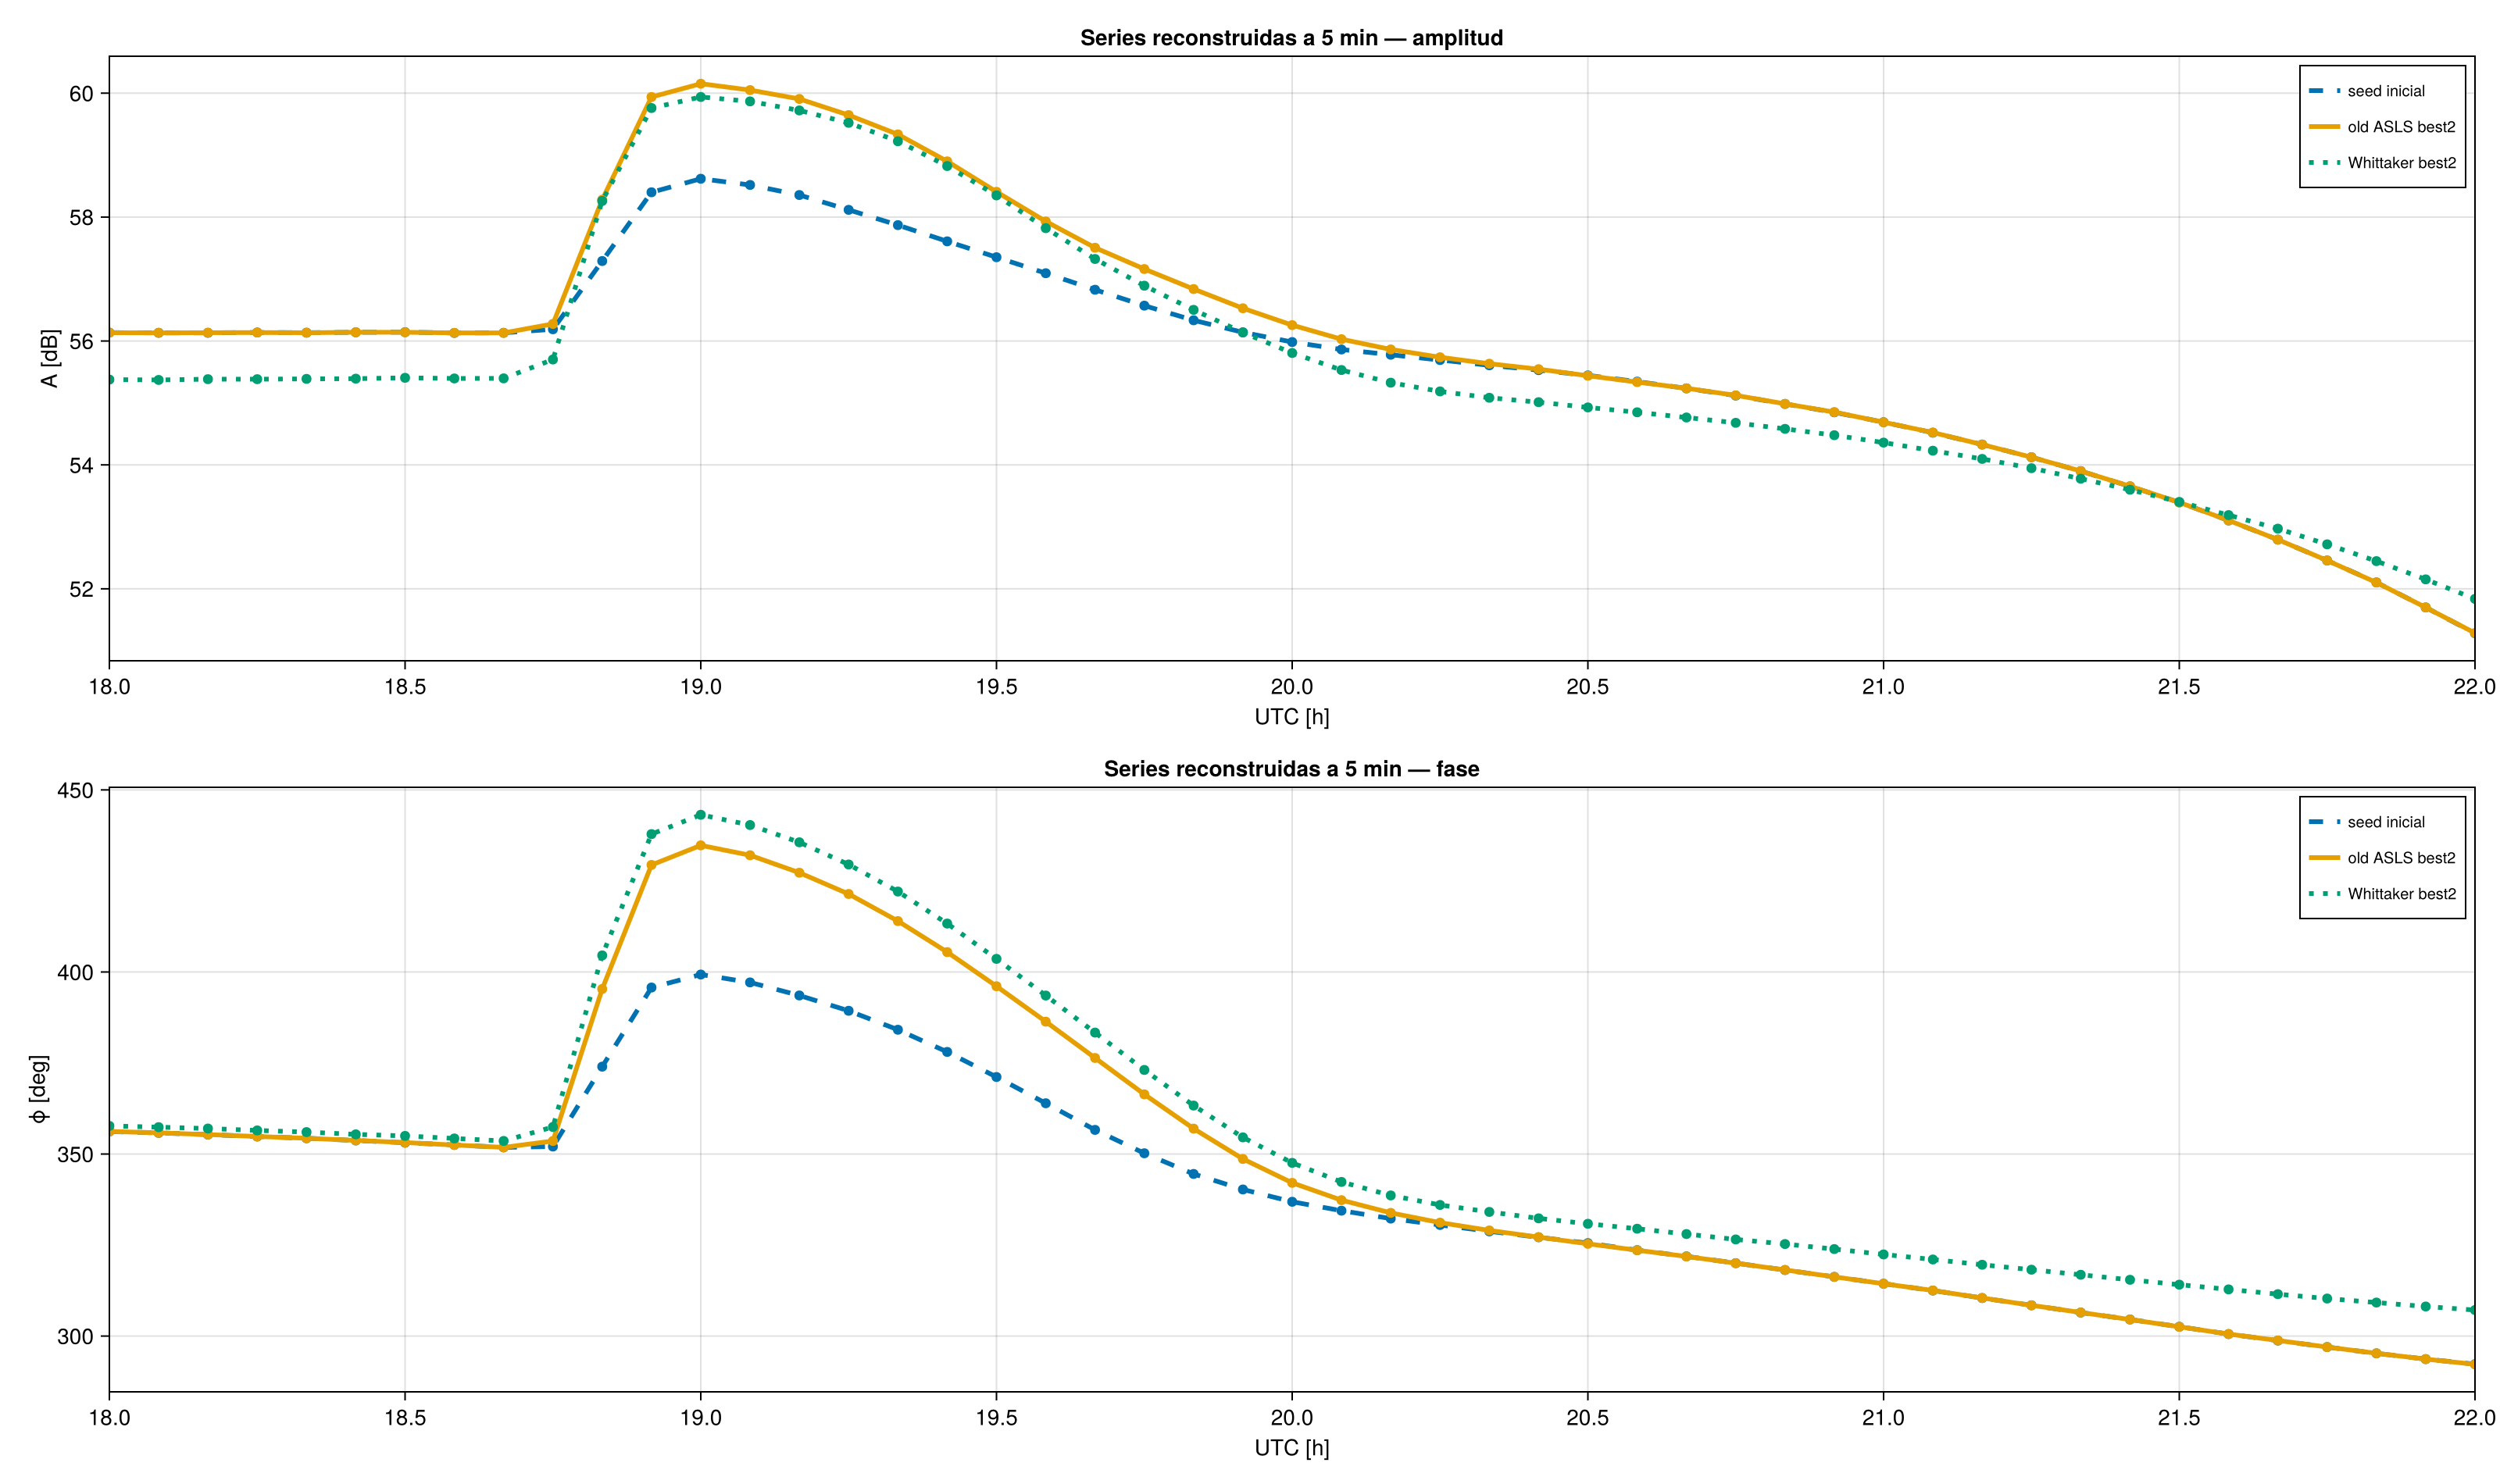

In [15]:
seed5 = curves_5min[:seed_inicial]
old5  = curves_5min[:oldASLS_best2]
whit5 = curves_5min[:whittaker_best2]
import CairoMakie as CM

fig = CM.Figure(size = (1600, 950))

axA = CM.Axis(
    fig[1, 1],
    title = "Series reconstruidas a 5 min — amplitud",
    xlabel = "UTC [h]",
    ylabel = "A [dB]",
)

axP = CM.Axis(
    fig[2, 1],
    title = "Series reconstruidas a 5 min — fase",
    xlabel = "UTC [h]",
    ylabel = "ϕ [deg]",
)

CM.lines!(axA, t_hours_5min, seed5.A, linewidth = 3, linestyle = :dash, label = "seed inicial")
CM.scatter!(axA, t_hours_5min, seed5.A)

CM.lines!(axA, t_hours_5min, old5.A, linewidth = 3, label = "old ASLS best2")
CM.scatter!(axA, t_hours_5min, old5.A)

CM.lines!(axA, t_hours_5min, whit5.A, linewidth = 3, linestyle = :dot, label = "Whittaker best2")
CM.scatter!(axA, t_hours_5min, whit5.A)

CM.lines!(axP, t_hours_5min, seed5.phi, linewidth = 3, linestyle = :dash, label = "seed inicial")
CM.scatter!(axP, t_hours_5min, seed5.phi)

CM.lines!(axP, t_hours_5min, old5.phi, linewidth = 3, label = "old ASLS best2")
CM.scatter!(axP, t_hours_5min, old5.phi)

CM.lines!(axP, t_hours_5min, whit5.phi, linewidth = 3, linestyle = :dot, label = "Whittaker best2")
CM.scatter!(axP, t_hours_5min, whit5.phi)

for ax in [axA, axP]
    CM.xlims!(ax, minimum(t_hours_5min), maximum(t_hours_5min))
    ax.xticks = 18:0.5:22
    CM.axislegend(ax, position = :rt, framevisible = true, labelsize = 10)
end

fig